In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Subpoint (a): Vandermonde Matrices for Different Bases

In this step, we define our input data: years (vector $t$) and population (vector $y$). Since we have 9 data points, our interpolating polynomial will be of the 8th degree, and the Vandermonde matrices will have dimensions of $9 \times 9$.

According to the instructions, we create four matrices for the following bases:
1. $\phi_{j}(t)=t^{j-1}$
2. $\phi_{j}(t)=(t-1900)^{j-1}$
3. $\phi_{j}(t)=(t-1940)^{j-1}$
4. $\phi_{j}(t)=((t-1940)/40)^{j-1}$

We use the `numpy` library and its broadcasting mechanism (adding a new axis with `np.newaxis`), which allows us to avoid loops and generate the matrices in a highly optimized way.

In [11]:

dates = np.array([1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980])
populations_cnt = np.array([76212168, 92228496, 106021537, 123202624, 132164569, 151325798, 179323175, 203302031, 226542199])

exponent = np.array([0,1,2,3,4,5,6,7,8])

# Scaled 1
dates_scaled_1 = dates
V_1 = dates_scaled_1[:,np.newaxis] ** exponent

# Scaled 2
dates_scaled_2 = (dates - 1900)
V_2 = dates_scaled_2[:,np.newaxis] ** exponent

# Scaled 3 
dates_scaled_3 = (dates - 1940)
V_3 = dates_scaled_3[:,np.newaxis] ** exponent

# Scaled 4
dates_scaled_4 = (dates - 1940) / 40
V_4 = dates_scaled_4[:,np.newaxis] ** exponent

## Subpoint (b): Condition numbers and Numerical Stability

We calculate the condition number for each of the generated matrices using the `numpy.linalg.cond` function. 

The condition number indicates how sensitive the solution of the linear system is to small numerical errors. A highly ill-conditioned matrix (large condition number) can lead to significant precision loss. By centering and scaling the data (as seen in Base 4), we can drastically improve the condition number and the numerical stability of our polynomial interpolation.

In [12]:
# Calculate the condition number for each matrix
cond_V_1 = np.linalg.cond(V_1)
cond_V_2 = np.linalg.cond(V_2)
cond_V_3 = np.linalg.cond(V_3)
cond_V_4 = np.linalg.cond(V_4)

# Print the results
print(f"Condition number for Base 1: {cond_V_1:.6e}")
print(f"Condition number for Base 2: {cond_V_2:.6e}")
print(f"Condition number for Base 3: {cond_V_3:.6e}")
print(f"Condition number for Base 4: {cond_V_4:.6e}")

Condition number for Base 1: 2.592914e+26
Condition number for Base 2: 5.757655e+15
Condition number for Base 3: 9.315536e+12
Condition number for Base 4: 1.605444e+03


## Subpoint (c): Polynomial Coefficients and Interpolation Plot

Using the best-conditioned basis (**Base 4**), we solve the linear system $ V_4 \mathbf{a} = \mathbf{y}$ to find the polynomial coefficients. 

To evaluate the polynomial efficiently and accurately, we implement **Horner's scheme**. We calculate the population values for every year between 1900 and 1990 at one-year intervals. Finally, we visualize the results by plotting the interpolation curve along with the original data points (nodes).

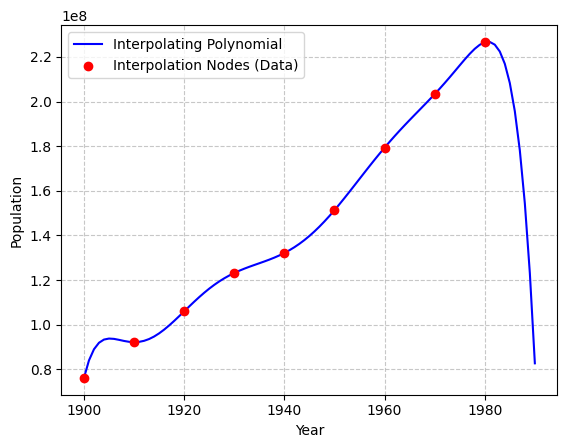

Polynomial coefficients (a): [ 1.32164569e+08  4.61307656e+07  1.02716315e+08  1.82527130e+08
 -3.74614715e+08 -3.42668456e+08  6.06291250e+08  1.89175576e+08
 -3.15180235e+08]


In [13]:
# 1. Solve the system of equations for the best-conditioned matrix (V_4)
a = np.linalg.solve(V_4,populations_cnt)

# 2. Define Horner's scheme for the specific transformation of Base 4
def horner_scheme(year,coeffs):
    scaled = (year - 1940) / 40
    res = 0
    
    for i in range(len(coeffs) - 1, -1, -1):
        res = res * scaled + coeffs[i]
    return res

# 3. Calculate values for the plot (1900-1990)
years = np.arange(1900,1991)
populations = [horner_scheme(year, a) for year in years]

# 4. Visualization
plt.plot(years,populations,label='Interpolating Polynomial', color='blue')
plt.scatter(dates, populations_cnt, color='red', zorder=5, label='Interpolation Nodes (Data)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Polynomial coefficients (a):", a)

## Subpoint (d): Extrapolation to 1990 and Relative Error

In this step, we use our 8th-degree polynomial to extrapolate the US population for the year 1990. 

High-degree polynomials are known to behave erratically outside the interpolation nodes (extrapolation). We will compare our model's prediction with the true historical value for 1990 (248,709,873) to calculate the relative error and observe this numerical instability in practice.

In [14]:
# 1. Define the true population for 1990
true_pop_1990 = 248709873

# 2. Predict the population for 1990 using our polynomial (Horner's scheme)
pred_pop_1990 = horner_scheme(1990, a)

# 3. Calculate the relative error: |true - predicted| / true
relative_error = abs(true_pop_1990 - pred_pop_1990) / true_pop_1990

# 4. Print the results
print(f"Predicted population in 1990: {pred_pop_1990:,.0f}")
print(f"True population in 1990:      {true_pop_1990:,.0f}")
print(f"Relative error:               {relative_error:.2%}")

Predicted population in 1990: 82,749,141
True population in 1990:      248,709,873
Relative error:               66.73%


## Subpoint (e): Lagrange Interpolating Polynomial

Instead of solving a system of linear equations, we can construct the polynomial directly using **Lagrange interpolation**. 

We implement a custom function based on the mathematical definition of Lagrange basis polynomials $l_j(t)$. Then, we evaluate this polynomial for every year between 1900 and 1990 at one-year intervals. Although this method yields the exact same polynomial curve as our previous approach, it has a higher computational cost of $O(n^2)$ per evaluation point.

In [15]:
# 1. Define a function for Lagrange interpolation
def lagrange_interpolation(x_nodes, y_nodes, x_eval):
    y_eval = np.zeros_like(x_eval, dtype=float)
    n = len(x_nodes)
    
    # Calculate the polynomial value for each evaluation point
    for i in range(n):
        # Calculate the i-th basis polynomial L_i(x)
        L_i = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if i != j:
                L_i *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
                
        # Add the weighted basis polynomial to the final result
        y_eval += y_nodes[i] * L_i
        
    return y_eval

# 2. Calculate values at one-year intervals (1900 to 1990)
years_eval = np.arange(1900, 1991)
popul_lagrange = lagrange_interpolation(dates, populations_cnt, years_eval)

# 3. Print a few results to verify it matches our previous Horner's scheme
popul_1950 = lagrange_interpolation(dates, populations_cnt, [1950])[0]
popul_1990 = lagrange_interpolation(dates, populations_cnt, [1990])[0]
popul_1980_1990 = [f"{val:.0f}" for val in popul_lagrange[80:]]

print(f"Polynomial coefficients for years 1980-1990 using Lagrange Method: {popul_1980_1990}")

Polynomial coefficients for years 1980-1990 using Lagrange Method: ['226542199', '226690002', '225469158', '222403117', '216909170', '208283006', '195681835', '178105993', '154378958', '123125676', '82749141']


In [16]:
print(f"Lagrange prediction for year 1950 (interpolation): {popul_1950:,.0f}")
print(f"Real count of population for year 1950: 151,325,798")
print(f"Lagrange prediction for year 1990 (extrapolation): {popul_1990:,.0f}")

Lagrange prediction for year 1950 (interpolation): 151,325,798
Real count of population for year 1950: 151,325,798
Lagrange prediction for year 1990 (extrapolation): 82,749,141


## Subpoint (f): Newton Interpolating Polynomial

The third method to construct the interpolating polynomial is the **Newton form**. This approach relies on **divided differences** to determine the coefficients. 

The Newton representation is particularly efficient when adding new data points, as it only requires calculating additional divided differences rather than recomputing the entire polynomial.  We implement the algorithm to calculate the divided difference table and then evaluate the polynomial for every year between 1900 and 1990 using a generalized Horner-like scheme for the Newton form.

In [17]:
# 1. Function to calculate the divided differences table
def divided_differences(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    # The first column is always y
    coef[:,0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    # The top row contains the coefficients c_0, c_1, ..., c_n
    return coef[0, :]

# 2. Function to evaluate the Newton polynomial
def newton_interpolation(x_nodes, coeffs, x_eval):
    n = len(coeffs)
    res = coeffs[n-1]
    # Generalized Horner's scheme for Newton form
    for i in range(n-2, -1, -1):
        res = res * (x_eval - x_nodes[i]) + coeffs[i]
    return res

# 3. Calculate coefficients and evaluate for years 1900-1990
newton_coeffs = divided_differences(dates, populations_cnt)
pop_newton = newton_interpolation(dates, newton_coeffs, years_eval)

# 4. Verify the results (should match previous methods)
print(f"Newton prediction for 1990: {pop_newton[-1]:,.0f}")

# Check first 5 years of the 1-year intervals
results_newton_df = pd.DataFrame({
    'Year': years_eval,
    'Population (Newton)': pop_newton
})
print("\nNewton one-year interval values (first 5):")
print(results_newton_df.head())

Newton prediction for 1990: 82,749,141

Newton one-year interval values (first 5):
   Year  Population (Newton)
0  1900         7.621217e+07
1  1901         8.404492e+07
2  1902         8.904632e+07
3  1903         9.195931e+07
4  1904         9.339358e+07


## Subpoint (g): Impact of Data Rounding on Interpolation

In this final step, we investigate the sensitivity of the polynomial interpolation to small changes in input data. We round the original population figures to the nearest million and find the new 8th-degree interpolating polynomial using the best-conditioned basis (**Base 4**).

We will compare the resulting coefficients with those obtained in subpoint (c) and analyze the relative error of extrapolation for 1990. This exercise demonstrates how small perturbations in input values can significantly alter the coefficients of high-degree polynomials and their long-term predictions.

In [18]:
# 1. Round population data to the nearest million
popul_rounded = np.round(populations_cnt, -6)

# 2. Find new coefficients for the best-conditioned basis (Base 4)
a_rounded = np.linalg.solve(V_4, popul_rounded)

# 3. Compare coefficients
coeff_comparison = pd.DataFrame({
    'Original Coefficients (c)': a,
    'Rounded Coefficients (g)': a_rounded,
    'Difference': a - a_rounded
})

print("Comparison of Polynomial Coefficients:")
print(coeff_comparison)

# 4. Calculate new extrapolation for 1990
pred_pop_1990_rounded = horner_scheme(1990, a_rounded)
relative_error_rounded = abs(true_pop_1990 - pred_pop_1990_rounded) / true_pop_1990

print(f"\nExtrapolation for 1990 (Rounded Data): {pred_pop_1990_rounded:,.0f}")
print(f"Relative error (Rounded Data):        {relative_error_rounded:.2%}")

Comparison of Polynomial Coefficients:
   Original Coefficients (c)  Rounded Coefficients (g)    Difference
0               1.321646e+08              1.320000e+08  1.645690e+05
1               4.613077e+07              4.595714e+07  1.736227e+05
2               1.027163e+08              1.001413e+08  2.575045e+06
3               1.825271e+08              1.811111e+08  1.416019e+06
4              -3.746147e+08             -3.567556e+08 -1.785916e+07
5              -3.426685e+08             -3.384889e+08 -4.179567e+06
6               6.062912e+08              5.703111e+08  3.598014e+07
7               1.891756e+08              1.869206e+08  2.254941e+06
8              -3.151802e+08             -2.941968e+08 -2.098341e+07

Extrapolation for 1990 (Rounded Data): 109,000,000
Relative error (Rounded Data):        56.17%


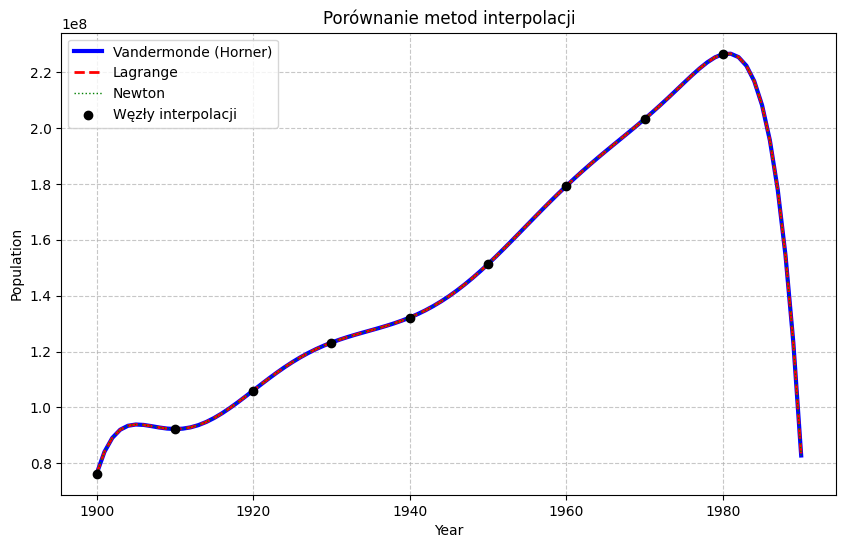

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(years, populations, label='Vandermonde (Horner)', linewidth=3, color='blue')
plt.plot(years, popul_lagrange, label='Lagrange', linewidth=2, linestyle='--', color='red')
plt.plot(years, pop_newton, label='Newton', linewidth=1, linestyle=':', color='green')

plt.scatter(dates, populations_cnt, color='black', zorder=5, label='Węzły interpolacji')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Porównanie metod interpolacji')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('interpolation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()